#РК №1 "Машинное обучение"
Вариант 3

Вареник Владислав Вячеславович

ИБМ3-65Б

In [ ]:
import kagglehub

path = kagglehub.dataset_download("carlolepelaars/toy-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'toy-dataset' dataset.
Path to dataset files: /kaggle/input/toy-dataset


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/carlolepelaars/toy-dataset/versions/1/toy_dataset.csv')
df.head()

,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No


Вымышленный набор данных для разведочного анализа данных (EDA) и тестирования простых моделей прогнозирования.



In [ ]:
df.isnull().sum().sum()

np.int64(0)

Добавляем фиктивные пропуски чтобы потом заполнить их

In [ ]:
mask = np.random.random(df.shape[0]) < 0.1
df.loc[mask, 'Income'] = np.nan

In [ ]:
df.isnull().sum().sum()

np.int64(14920)

In [ ]:
df["Income"].median() # медиана

93667.5

На основе медианного значения в качестве границы, поделим цену на 2 категории

In [ ]:
df['income_category'] = np.where(df["Income"] <= df["Income"].median(), 'дешевое', 'дорогое')

In [ ]:
df_clean = df.dropna()  # удаляем все строки, содержащие хотя бы один NaN


In [ ]:
df_clean.head()

,Number,City,Gender,Age,Income,Illness,income_category
0,1,Dallas,Male,41,40367.0,No,дешевое
1,2,Dallas,Male,54,45084.0,No,дешевое
2,3,Dallas,Male,42,52483.0,No,дешевое
3,4,Dallas,Male,40,40941.0,No,дешевое
4,5,Dallas,Male,46,50289.0,No,дешевое


Категоризируем

In [ ]:
mapping = {'дешевое': 0, 'дорогое': 1}
df_clean['income_category_binary'] = df_clean['income_category'].map(mapping)

/tmp/ipykernel_3288/1494545420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['income_category_binary'] = df_clean['income_category'].map(mapping)


In [ ]:
df_clean.head()

,Number,City,Gender,Age,Income,Illness,income_category,income_category_binary
0,1,Dallas,Male,41,40367.0,No,дешевое,0
1,2,Dallas,Male,54,45084.0,No,дешевое,0
2,3,Dallas,Male,42,52483.0,No,дешевое,0
3,4,Dallas,Male,40,40941.0,No,дешевое,0
4,5,Dallas,Male,46,50289.0,No,дешевое,0


In [ ]:
df_clean['Illness'] = df_clean['Illness'].astype(str).str.strip().str.upper()
df_clean['Illness'] = df_clean['Illness'].map({'NO': 0, 'YES': 1})

/tmp/ipykernel_3288/311215367.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Illness'] = df_clean['Illness'].astype(str).str.strip().str.upper()
/tmp/ipykernel_3288/311215367.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Illness'] = df_clean['Illness'].map({'NO': 0, 'YES': 1})


In [ ]:
df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})

/tmp/ipykernel_3288/1866481419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})


In [ ]:
analysis_cols = ['Age', 'Income', 'Illness', 'income_category_binary']
df_clean[analysis_cols].head()

,Age,Income,Illness,income_category_binary
0,41,40367.0,0,0
1,54,45084.0,0,0
2,42,52483.0,0,0
3,40,40941.0,0,0
4,46,50289.0,0,0


Построим матрицу корреляций

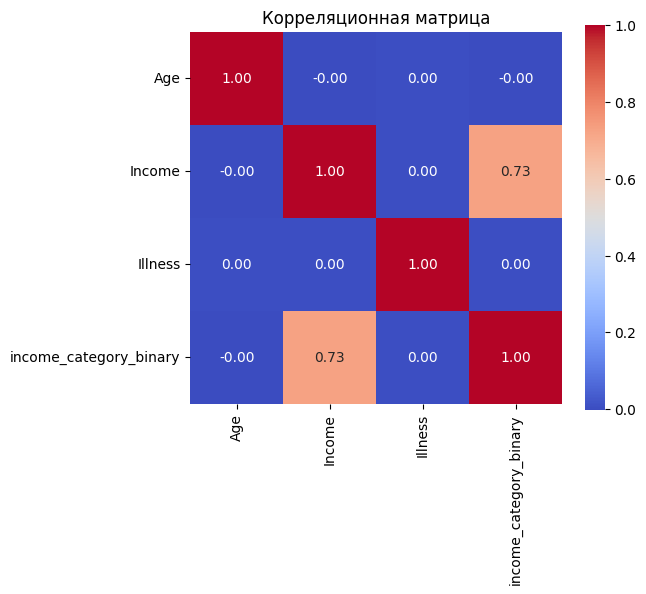

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[analysis_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица')
plt.show()

Так же построим набор графиков для поиска зависимостей между разными атрибутами

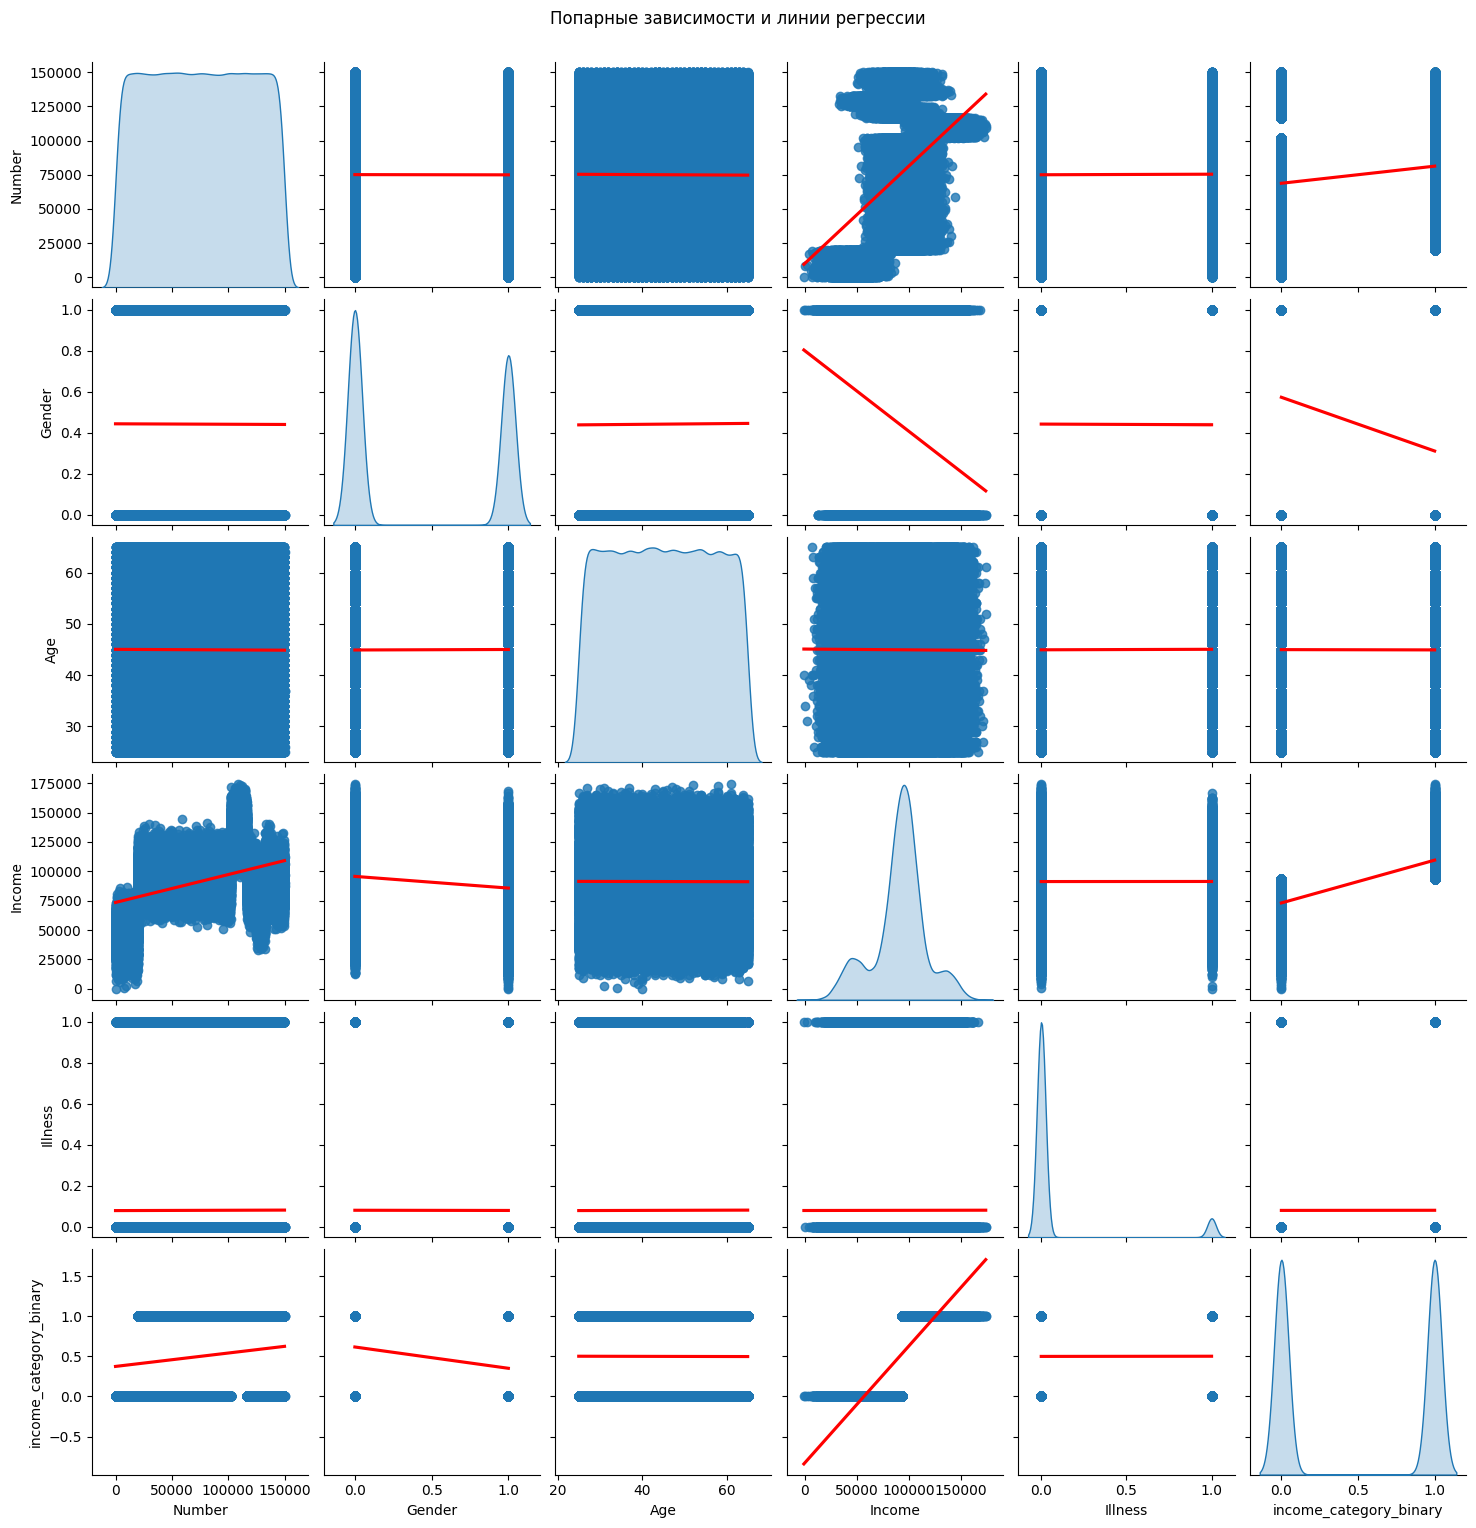

In [ ]:
sns.pairplot(df_clean, kind='reg', diag_kind='kde', plot_kws={'line_kws': {'color': 'red'}})
plt.suptitle('Попарные зависимости и линии регрессии', y=1.02)
plt.show()

По результатам разведочного анализа можно сделать вывод что набор данных не подходит для последующего построения предсказательных моделей из-за отсутствия кореляции между атрибутами, это можно объяснить тем что данные являются сгенерированными на основе классических методов распределения без взаимосвязи между атрибутами